# 06 — Decision Tree: análisis de importancia

Este notebook utiliza un árbol de decisión regularizado para estudiar la utilidad de las variables desde una perspectiva no lineal. No define todavía el árbol final ni consulta el holdout temporal de 2017: cualquier reducción de variables deberá validarse primero mediante ablación sobre 2015–2016.

El árbol parte del conjunto base depurado posterior al baseline. Conserva `LeadTime` continuo y los conteos originales para permitir que el algoritmo aprenda sus propios cortes; excluye `ArrivalDateWeekNumber` por su redundancia con el mes.

## Imports y resolución de la raíz

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.metrics import RocCurveDisplay
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree

pd.set_option("display.max_columns", None)

In [2]:
def find_project_root(start_path=None):
    """Busca la raíz del repositorio a partir del directorio actual."""
    start = Path(start_path or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw").is_dir() and (candidate / "src").is_dir():
            return candidate
    return None

PROJECT_ROOT = find_project_root()
if PROJECT_ROOT is None:
    raise FileNotFoundError("No se encontró la raíz local del proyecto.")

project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

print(f"Raíz del proyecto: {PROJECT_ROOT}")

Raíz del proyecto: C:\Code\Vialesoft\Vialesoft_Devlab\Mini_Proyectos\Machine_Learning\Obligatorio2026


In [3]:
from src.config import RANDOM_STATE, RAW_DATA_DIR
from src.data import (
    combine_hotel_datasets,
    load_csv_with_fallback,
    make_temporal_holdout_split,
    normalize_text_values,
)
from src.evaluation import (
    cross_validate_model,
    evaluate_binary_classifier,
    get_grid_results,
    get_stratified_group_cross_validation,
    run_grid_search,
)
from src.features import (
    build_base_feature_set,
    get_feature_types,
    make_exact_feature_groups,
    remove_redundant_base_features,
)
from src.plots import plot_confusion_matrix
from src.preprocessing import build_tabular_preprocessor

## Carga e integración de los datos

In [4]:
H1_URL = "https://raw.githubusercontent.com/Lithium582/Obligatorio2026/refs/heads/main/data/raw/H1.csv"
H2_URL = "https://raw.githubusercontent.com/Lithium582/Obligatorio2026/refs/heads/main/data/raw/H2.csv"

h1_df = load_csv_with_fallback(RAW_DATA_DIR / "H1.csv", H1_URL)
h2_df = load_csv_with_fallback(RAW_DATA_DIR / "H2.csv", H2_URL)
bookings_df = combine_hotel_datasets(h1_df, h2_df)
bookings_df = normalize_text_values(bookings_df)

print(f"Dataset integrado: {bookings_df.shape[0]:,} filas y {bookings_df.shape[1]} columnas.")

Dataset integrado: 119,390 filas y 32 columnas.


## Conjunto base para árboles

No se trasladan automáticamente las transformaciones elegidas para Logistic Regression. Un árbol puede aprender cortes sobre `LeadTime`, reconocer el umbral de solicitudes especiales y construir interacciones sin agregar representaciones redundantes.

In [5]:
X_reference, y = build_base_feature_set(bookings_df)
X = remove_redundant_base_features(X_reference)
numeric_features, categorical_features = get_feature_types(X)

if "ArrivalDateWeekNumber" in X.columns:
    raise ValueError("ArrivalDateWeekNumber debe quedar fuera del conjunto depurado.")
if "LeadTime" not in X.columns:
    raise ValueError("El árbol debe conservar LeadTime continuo.")

feature_summary = pd.DataFrame({
    "group": ["Numeric/binary", "Categorical", "Total"],
    "count": [len(numeric_features), len(categorical_features), X.shape[1]],
    "columns": [numeric_features, categorical_features, list(X.columns)],
})
display(feature_summary)
print("Features eliminadas respecto al baseline:", sorted(set(X_reference.columns) - set(X.columns)))

,group,count,columns
0,Numeric/binary,16,"[LeadTime, ArrivalDateYear, ArrivalDateDayOfMo..."
1,Categorical,8,"[HotelType, ArrivalDateMonth, Meal, Country, M..."
2,Total,24,"[HotelType, LeadTime, ArrivalDateYear, Arrival..."


Features eliminadas respecto al baseline: ['ArrivalDateWeekNumber']


## Desarrollo, holdout reservado y grupos

El holdout temporal se separa para impedir su uso accidental, pero no se evalúa en este notebook. Todas las decisiones de complejidad e importancia se toman sobre 2015–2016.

In [6]:
X_train, X_holdout, y_train, y_holdout = make_temporal_holdout_split(
    X,
    y,
    period_values=X["ArrivalDateYear"],
    validation_period=2017,
)
train_groups = make_exact_feature_groups(X_train)

split_summary = pd.DataFrame({
    "subset": ["Development (2015-2016)", "Reserved holdout (2017 Jan-Aug)"],
    "rows": [len(X_train), len(X_holdout)],
    "cancellation_rate": [y_train.mean(), y_holdout.mean()],
    "used_for_selection": [True, False],
})
display(split_summary.round(4))

,subset,rows,cancellation_rate,used_for_selection
0,Development (2015-2016),78703,0.3619,True
1,Reserved holdout (2017 Jan-Aug),40687,0.3870,False


## Árbol regularizado y búsqueda de complejidad

No se escalan las variables numéricas porque los árboles sólo comparan valores con umbrales. `min_samples_leaf` impide crear reglas sustentadas por unas pocas reservas, algo especialmente importante ante países y categorías infrecuentes. La grilla contiene 48 configuraciones y utiliza ROC AUC.

In [7]:
tree_preprocessor = build_tabular_preprocessor(
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    scale_numeric=False,
)

tree_pipeline = Pipeline(steps=[
    ("preprocessor", tree_preprocessor),
    ("model", DecisionTreeClassifier(
        min_samples_split=100,
        random_state=RANDOM_STATE,
    )),
])

param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [4, 6, 8, 10],
    "model__min_samples_leaf": [50, 100, 250],
    "model__class_weight": [None, "balanced"],
}

grid_size = np.prod([len(values) for values in param_grid.values()])
print(f"Configuraciones: {grid_size}; ajustes con 5 folds: {grid_size * 5}.")

Configuraciones: 48; ajustes con 5 folds: 240.


In [8]:
group_cv = get_stratified_group_cross_validation(n_splits=5)
tree_search = run_grid_search(
    estimator=tree_pipeline,
    param_grid=param_grid,
    X=X_train,
    y=y_train,
    scoring="roc_auc",
    cv=group_cv,
    groups=train_groups,
    n_jobs=-1,
)

grid_results = get_grid_results(tree_search)
grid_results["train_validation_gap"] = (
    grid_results["mean_train_score"] - grid_results["mean_test_score"]
)
result_columns = [
    "params", "mean_train_score", "mean_test_score",
    "std_test_score", "train_validation_gap", "rank_test_score",
]
display(grid_results[result_columns].head(10).round(6))
print(f"Mejores parámetros: {tree_search.best_params_}")
print(f"Mejor ROC AUC CV: {tree_search.best_score_:.6f}")

,params,mean_train_score,mean_test_score,std_test_score,train_validation_gap,rank_test_score
0,"{'model__class_weight': 'balanced', 'model__cr...",0.934135,0.923034,0.004718,0.011102,1
1,"{'model__class_weight': 'balanced', 'model__cr...",0.936274,0.921833,0.005417,0.014441,2
2,"{'model__class_weight': None, 'model__criterio...",0.935696,0.921450,0.005597,0.014246,3
3,"{'model__class_weight': None, 'model__criterio...",0.933312,0.921448,0.004487,0.011864,4
4,"{'model__class_weight': 'balanced', 'model__cr...",0.935879,0.920426,0.005647,0.015453,5
5,"{'model__class_weight': 'balanced', 'model__cr...",0.933360,0.919909,0.006034,0.013450,6
6,"{'model__class_weight': None, 'model__criterio...",0.935733,0.918399,0.009325,0.017334,7
7,"{'model__class_weight': None, 'model__criterio...",0.932574,0.918237,0.007918,0.014337,8
8,"{'model__class_weight': 'balanced', 'model__cr...",0.925148,0.917766,0.003936,0.007381,9
9,"{'model__class_weight': 'balanced', 'model__cr...",0.926187,0.917352,0.004124,0.008836,10


Mejores parámetros: {'model__class_weight': 'balanced', 'model__criterion': 'entropy', 'model__max_depth': 10, 'model__min_samples_leaf': 100}
Mejor ROC AUC CV: 0.923034


## Complejidad y estructura superior

El árbol elegido por CV se ajusta automáticamente sobre todo desarrollo. Se muestran su profundidad, cantidad de hojas y únicamente los primeros niveles; el gráfico no pretende representar todas sus reglas.

,depth,leaves,nodes
0,10,181,361


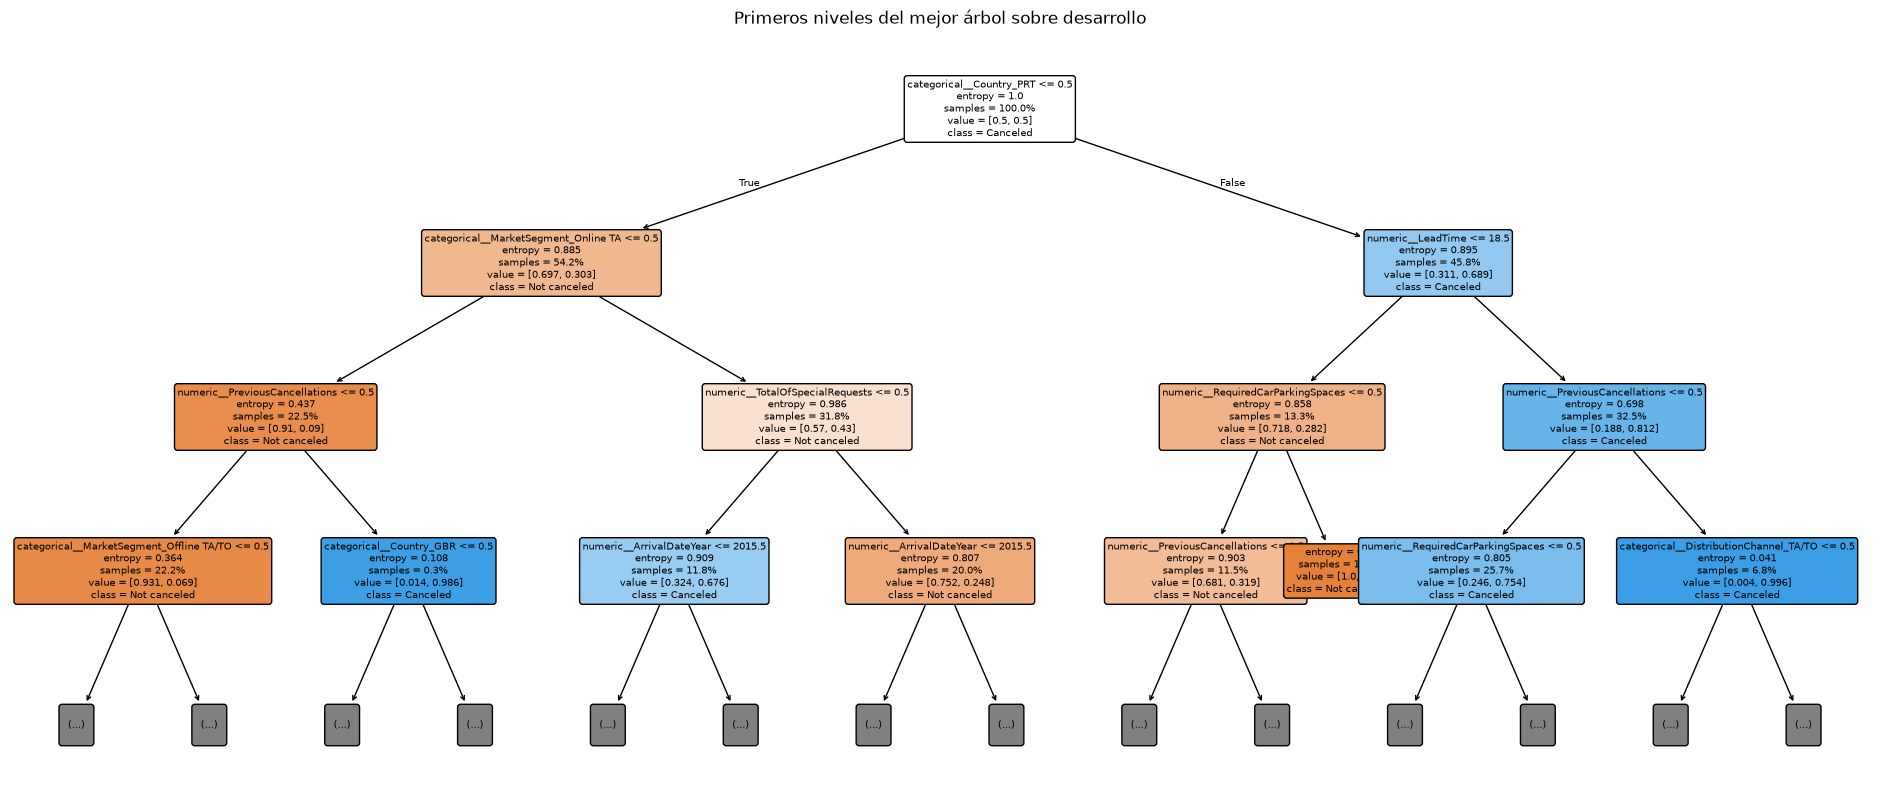

In [9]:
best_tree_model = tree_search.best_estimator_
fitted_preprocessor = best_tree_model.named_steps["preprocessor"]
fitted_tree = best_tree_model.named_steps["model"]
transformed_feature_names = fitted_preprocessor.get_feature_names_out()

tree_complexity = pd.DataFrame([{
    "depth": fitted_tree.get_depth(),
    "leaves": fitted_tree.get_n_leaves(),
    "nodes": fitted_tree.tree_.node_count,
}])
display(tree_complexity)

plt.figure(figsize=(24, 10))
plot_tree(
    fitted_tree,
    feature_names=transformed_feature_names,
    class_names=["Not canceled", "Canceled"],
    max_depth=3,
    filled=True,
    rounded=True,
    proportion=True,
    fontsize=7,
)
plt.title("Primeros niveles del mejor árbol sobre desarrollo")
plt.show()

## Importancia estructural: impureza, splits y profundidad

La importancia por impureza suma cuánto reducen el criterio los splits de cada variable. La cantidad de splits indica cuántas veces fue utilizada y la primera profundidad señala qué tan temprano aparece. Las columnas one-hot se agrupan nuevamente por feature original.

Estas medidas describen la estructura del árbol, pero pueden favorecer variables continuas o categóricas con muchas alternativas. Por eso no se usarán solas para eliminar features.

In [10]:
categorical_pipeline = fitted_preprocessor.named_transformers_["categorical"]
fitted_onehot = categorical_pipeline.named_steps["onehot"]
transformed_source_features = [*numeric_features]
for feature, categories in zip(categorical_features, fitted_onehot.categories_):
    transformed_source_features.extend([feature] * len(categories))

if len(transformed_source_features) != len(transformed_feature_names):
    raise ValueError("No se pudo mapear cada columna transformada a su feature original.")

used_feature_indices = fitted_tree.tree_.feature
valid_feature_indices = used_feature_indices[used_feature_indices >= 0]
split_counts = np.bincount(
    valid_feature_indices, minlength=len(transformed_feature_names)
)

node_depths = np.zeros(fitted_tree.tree_.node_count, dtype=int)
stack = [(0, 0)]
while stack:
    node_id, depth = stack.pop()
    node_depths[node_id] = depth
    left_child = fitted_tree.tree_.children_left[node_id]
    right_child = fitted_tree.tree_.children_right[node_id]
    if left_child != right_child:
        stack.extend([(left_child, depth + 1), (right_child, depth + 1)])

first_depth = np.full(len(transformed_feature_names), np.nan)
for node_id, feature_index in enumerate(used_feature_indices):
    if feature_index >= 0:
        current_depth = node_depths[node_id]
        if np.isnan(first_depth[feature_index]) or current_depth < first_depth[feature_index]:
            first_depth[feature_index] = current_depth

transformed_tree_importance = pd.DataFrame({
    "transformed_feature": transformed_feature_names,
    "source_feature": transformed_source_features,
    "impurity_importance": fitted_tree.feature_importances_,
    "split_count": split_counts,
    "first_depth": first_depth,
})
structural_importance = (
    transformed_tree_importance
    .groupby("source_feature", as_index=False)
    .agg(
        impurity_importance=("impurity_importance", "sum"),
        split_count=("split_count", "sum"),
        first_depth=("first_depth", "min"),
    )
    .sort_values("impurity_importance", ascending=False)
)
display(structural_importance.round(6))

,source_feature,impurity_importance,split_count,first_depth
6,Country,0.217111,10,0.0
14,LeadTime,0.200184,40,1.0
15,MarketSegment,0.145612,14,1.0
23,TotalOfSpecialRequests,0.093429,9,2.0
18,PreviousCancellations,0.090518,3,2.0
19,RequiredCarParkingSpaces,0.069952,5,2.0
7,CustomerType,0.051857,8,4.0
3,ArrivalDateYear,0.050476,8,3.0
2,ArrivalDateMonth,0.016279,19,4.0
9,DistributionChannel,0.013805,10,3.0


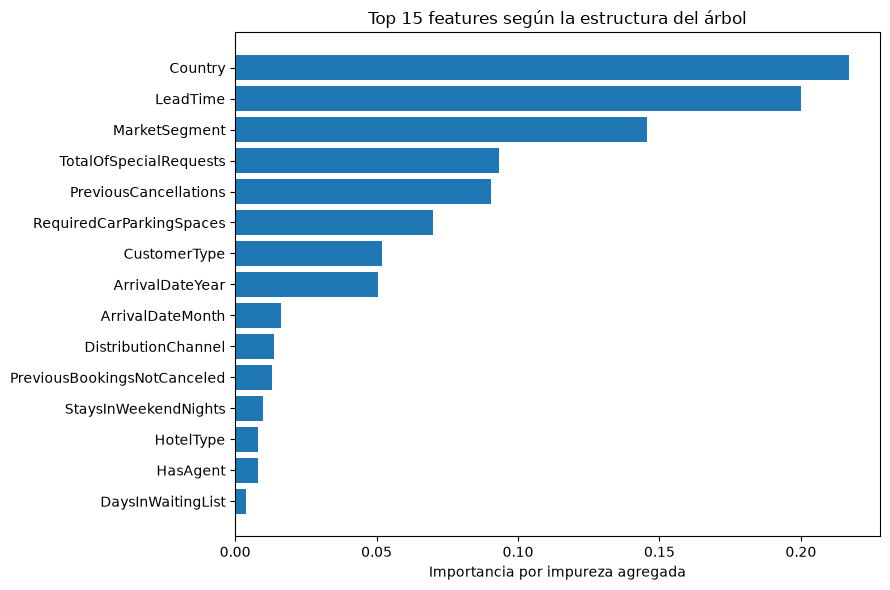

In [11]:
top_structural = structural_importance.head(15).sort_values(
    "impurity_importance", ascending=True
)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_structural["source_feature"], top_structural["impurity_importance"])
ax.set_xlabel("Importancia por impureza agregada")
ax.set_title("Top 15 features según la estructura del árbol")
plt.tight_layout()
plt.show()

## Importancia por permutación fuera de muestra

La evidencia principal se calcula dentro de cada fold. El mejor esquema se ajusta con cuatro folds y cada feature original se permuta en el fold restante. La caída de ROC AUC mide cuánto depende el modelo de esa variable. Se realizan cinco permutaciones por feature y no se utiliza el holdout temporal.

Una importancia cercana a cero no demuestra que la variable sea inútil: puede compartir información con otra. Una importancia negativa indica que permutarla mejoró ligeramente el resultado en ese fold y debe interpretarse como ausencia de evidencia estable, no como causalidad negativa.

In [12]:
permutation_fold_records = []
permutation_cv = get_stratified_group_cross_validation(n_splits=5)

for fold, (fit_indices, validation_indices) in enumerate(
    permutation_cv.split(X_train, y_train, groups=train_groups), start=1
):
    fold_model = clone(best_tree_model)
    fold_model.fit(X_train.iloc[fit_indices], y_train.iloc[fit_indices])
    fold_permutation = permutation_importance(
        fold_model,
        X_train.iloc[validation_indices],
        y_train.iloc[validation_indices],
        scoring="roc_auc",
        n_repeats=5,
        random_state=RANDOM_STATE + fold,
        n_jobs=-1,
    )
    permutation_fold_records.extend([
        {
            "fold": fold,
            "feature": feature,
            "importance_mean": importance_mean,
            "importance_std_within_fold": importance_std,
        }
        for feature, importance_mean, importance_std in zip(
            X_train.columns,
            fold_permutation.importances_mean,
            fold_permutation.importances_std,
        )
    ])
    print(f"Fold {fold} completado.")

permutation_fold_results = pd.DataFrame(permutation_fold_records)
permutation_summary = (
    permutation_fold_results
    .groupby("feature", as_index=False)
    .agg(
        permutation_importance_mean=("importance_mean", "mean"),
        permutation_importance_std_across_folds=("importance_mean", "std"),
        positive_fold_share=("importance_mean", lambda values: values.gt(0).mean()),
    )
    .sort_values("permutation_importance_mean", ascending=False)
)
display(permutation_summary.round(6))

Fold 1 completado.
Fold 2 completado.
Fold 3 completado.
Fold 4 completado.
Fold 5 completado.


,feature,permutation_importance_mean,permutation_importance_std_across_folds,positive_fold_share
6,Country,0.154278,0.009787,1.0
15,MarketSegment,0.084742,0.005536,1.0
18,PreviousCancellations,0.060572,0.008352,1.0
14,LeadTime,0.059171,0.002236,1.0
23,TotalOfSpecialRequests,0.052020,0.003936,1.0
3,ArrivalDateYear,0.045880,0.003922,1.0
19,RequiredCarParkingSpaces,0.043144,0.002614,1.0
7,CustomerType,0.042737,0.004838,1.0
12,HotelType,0.004705,0.001289,1.0
2,ArrivalDateMonth,0.004264,0.001071,1.0


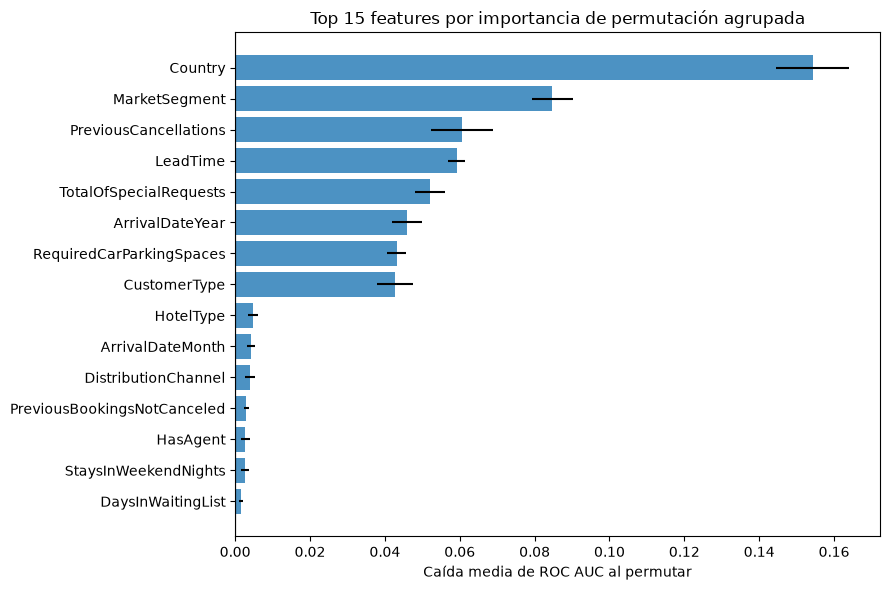

In [13]:
top_permutation = permutation_summary.head(15).sort_values(
    "permutation_importance_mean", ascending=True
)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(
    top_permutation["feature"],
    top_permutation["permutation_importance_mean"],
    xerr=top_permutation["permutation_importance_std_across_folds"],
    alpha=0.8,
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Caída media de ROC AUC al permutar")
ax.set_title("Top 15 features por importancia de permutación agrupada")
plt.tight_layout()
plt.show()

## Comparación de evidencias

La tabla combina la importancia estructural con la permutación fuera de muestra. Las candidatas a ablación serán variables con importancia de permutación mínima o inestable y poca participación estructural. No se eliminará ninguna feature únicamente porque un árbol particular no la haya utilizado.

In [14]:
importance_comparison = (
    structural_importance
    .merge(
        permutation_summary,
        left_on="source_feature",
        right_on="feature",
        how="outer",
    )
    .drop(columns="feature")
    .sort_values("permutation_importance_mean", ascending=False)
)
display(importance_comparison.round(6))

low_evidence_candidates = importance_comparison.loc[
    importance_comparison["permutation_importance_mean"].le(0.0005)
    & importance_comparison["positive_fold_share"].le(0.6)
    & importance_comparison["impurity_importance"].le(0.005)
].copy()
print("Candidatas para revisar mediante ablación; no son eliminaciones automáticas:")
display(low_evidence_candidates.round(6))

,source_feature,impurity_importance,split_count,first_depth,permutation_importance_mean,permutation_importance_std_across_folds,positive_fold_share
6,Country,0.217111,10,0.0,0.154278,0.009787,1.0
15,MarketSegment,0.145612,14,1.0,0.084742,0.005536,1.0
18,PreviousCancellations,0.090518,3,2.0,0.060572,0.008352,1.0
14,LeadTime,0.200184,40,1.0,0.059171,0.002236,1.0
23,TotalOfSpecialRequests,0.093429,9,2.0,0.052020,0.003936,1.0
3,ArrivalDateYear,0.050476,8,3.0,0.045880,0.003922,1.0
19,RequiredCarParkingSpaces,0.069952,5,2.0,0.043144,0.002614,1.0
7,CustomerType,0.051857,8,4.0,0.042737,0.004838,1.0
12,HotelType,0.008072,6,6.0,0.004705,0.001289,1.0
2,ArrivalDateMonth,0.016279,19,4.0,0.004264,0.001071,1.0


Candidatas para revisar mediante ablación; no son eliminaciones automáticas:


,source_feature,impurity_importance,split_count,first_depth,permutation_importance_mean,permutation_importance_std_across_folds,positive_fold_share
16,Meal,0.002253,5,7.0,0.000223,0.000255,0.6
11,HasCompany,0.000000,0,NaN,0.000028,0.000064,0.2
5,Children,0.000000,0,NaN,0.000000,0.000000,0.0
13,IsRepeatedGuest,0.000000,0,NaN,0.000000,0.000000,0.0
4,Babies,0.000000,0,NaN,0.000000,0.000000,0.0
20,ReservedRoomType,0.000266,2,5.0,-0.000008,0.000052,0.2
1,ArrivalDateDayOfMonth,0.001922,13,6.0,-0.000039,0.000274,0.4


## Ablación de variables con baja evidencia

Se comparan dos podas acumulativas contra las 24 variables de referencia. La poda estricta elimina únicamente features sin uso estructural y sin aporte por permutación. La ampliada agrega variables con participación marginal e importancia fuera de muestra nula o inestable.

El modelo y sus hiperparámetros permanecen fijos para aislar el efecto del conjunto de variables. El holdout temporal continúa reservado.

In [15]:
STRICT_TREE_PRUNING = [
    "Babies",
    "Children",
    "IsRepeatedGuest",
    "HasCompany",
]
EXPANDED_TREE_PRUNING = [
    *STRICT_TREE_PRUNING,
    "ReservedRoomType",
    "ArrivalDateDayOfMonth",
    "Meal",
]

pruning_feature_sets = {
    "Reference | 24 features": X_train.copy(),
    "Strict pruning | 20 features": X_train.drop(columns=STRICT_TREE_PRUNING),
    "Expanded pruning | 17 features": X_train.drop(columns=EXPANDED_TREE_PRUNING),
}
pruning_groups = make_exact_feature_groups(
    pruning_feature_sets["Expanded pruning | 17 features"]
)

pruning_summary = pd.DataFrame([
    {
        "configuration": name,
        "feature_count": frame.shape[1],
        "removed_vs_reference": sorted(set(X_train.columns).difference(frame.columns)),
    }
    for name, frame in pruning_feature_sets.items()
])
display(pruning_summary)

,configuration,feature_count,removed_vs_reference
0,Reference | 24 features,24,[]
1,Strict pruning | 20 features,20,"[Babies, Children, HasCompany, IsRepeatedGuest]"
2,Expanded pruning | 17 features,17,"[ArrivalDateDayOfMonth, Babies, Children, HasC..."


In [16]:
def build_fixed_tree_pipeline(X_candidate):
    candidate_numeric, candidate_categorical = get_feature_types(
        X_candidate, require_all_categorical=False
    )
    candidate_preprocessor = build_tabular_preprocessor(
        numeric_features=candidate_numeric,
        categorical_features=candidate_categorical,
        scale_numeric=False,
    )
    return Pipeline(steps=[
        ("preprocessor", candidate_preprocessor),
        ("model", DecisionTreeClassifier(
            criterion=tree_search.best_params_["model__criterion"],
            max_depth=tree_search.best_params_["model__max_depth"],
            min_samples_leaf=tree_search.best_params_["model__min_samples_leaf"],
            min_samples_split=100,
            class_weight=tree_search.best_params_["model__class_weight"],
            random_state=RANDOM_STATE,
        )),
    ])


pruning_records = []
pruning_fold_records = []
for configuration_name, X_pruned in pruning_feature_sets.items():
    pruning_cv = get_stratified_group_cross_validation(n_splits=5)
    scores = cross_validate_model(
        estimator=build_fixed_tree_pipeline(X_pruned),
        X=X_pruned,
        y=y_train,
        scoring="roc_auc",
        cv=pruning_cv,
        groups=pruning_groups,
        n_jobs=-1,
    )
    pruning_records.append({
        "configuration": configuration_name,
        "feature_count": X_pruned.shape[1],
        "cv_roc_auc_mean": scores.mean(),
        "cv_roc_auc_std": scores.std(),
    })
    pruning_fold_records.extend([
        {"configuration": configuration_name, "fold": fold, "roc_auc": score}
        for fold, score in enumerate(scores, start=1)
    ])

pruning_results = pd.DataFrame(pruning_records)
pruning_reference_score = pruning_results.loc[
    pruning_results["configuration"].eq("Reference | 24 features"),
    "cv_roc_auc_mean",
].iloc[0]
pruning_results["delta_vs_reference"] = (
    pruning_results["cv_roc_auc_mean"] - pruning_reference_score
)
pruning_results = pruning_results.sort_values(
    "cv_roc_auc_mean", ascending=False
).reset_index(drop=True)
pruning_fold_results = pd.DataFrame(pruning_fold_records)

display(pruning_results.round(6))
display(pruning_fold_results.pivot(
    index="fold", columns="configuration", values="roc_auc"
).round(6))

,configuration,feature_count,cv_roc_auc_mean,cv_roc_auc_std,delta_vs_reference
0,Expanded pruning | 17 features,17,0.924418,0.003764,0.000668
1,Strict pruning | 20 features,20,0.923752,0.004072,0.000003
2,Reference | 24 features,24,0.923749,0.004060,0.000000


configuration,Expanded pruning | 17 features,Reference | 24 features,Strict pruning | 20 features
fold,,,
1,0.922183,0.921930,0.921899
2,0.918363,0.916941,0.916941
3,0.927435,0.927212,0.927212
4,0.928814,0.928255,0.928299
5,0.925293,0.924408,0.924408


### Decisión de poda

La poda estricta obtuvo prácticamente el mismo resultado que la referencia. La poda ampliada alcanzó ROC AUC medio 0,924418 frente a 0,923749, mejoró los cinco folds y redujo la desviación de 0,004060 a 0,003764. Se selecciona por tanto el conjunto ampliado de 17 variables.

La eliminación de `ArrivalDateDayOfMonth`, pese a haber participado en 13 splits, mejoró la validación fuera de muestra. Esto confirma que uso estructural no equivale necesariamente a utilidad generalizable. `ArrivalDateYear` y `StaysInWeekNights` se conservan.

## Búsqueda final sobre el conjunto podado

La primera grilla eligió la profundidad máxima disponible. Antes de consultar 2017 se amplía únicamente el rango relevante, manteniendo `entropy` y pesos balanceados. Se comparan 16 configuraciones sobre los mismos grupos y folds utilizados en la ablación.

In [17]:
X_tree_final_train = pruning_feature_sets["Expanded pruning | 17 features"].copy()
X_tree_final_holdout = X_holdout.drop(columns=EXPANDED_TREE_PRUNING)
final_numeric_features, final_categorical_features = get_feature_types(
    X_tree_final_train, require_all_categorical=False
)
final_tree_preprocessor = build_tabular_preprocessor(
    numeric_features=final_numeric_features,
    categorical_features=final_categorical_features,
    scale_numeric=False,
)
final_tree_pipeline = Pipeline(steps=[
    ("preprocessor", final_tree_preprocessor),
    ("model", DecisionTreeClassifier(
        criterion="entropy",
        class_weight="balanced",
        min_samples_split=100,
        random_state=RANDOM_STATE,
    )),
])
final_tree_param_grid = {
    "model__max_depth": [8, 10, 12, 14],
    "model__min_samples_leaf": [75, 100, 150, 250],
}
final_grid_size = np.prod([len(values) for values in final_tree_param_grid.values()])
print(f"Configuraciones: {final_grid_size}; ajustes con 5 folds: {final_grid_size * 5}.")

Configuraciones: 16; ajustes con 5 folds: 80.


In [18]:
final_tree_cv = get_stratified_group_cross_validation(n_splits=5)
final_tree_search = run_grid_search(
    estimator=final_tree_pipeline,
    param_grid=final_tree_param_grid,
    X=X_tree_final_train,
    y=y_train,
    scoring="roc_auc",
    cv=final_tree_cv,
    groups=pruning_groups,
    n_jobs=-1,
)
final_tree_grid_results = get_grid_results(final_tree_search)
final_tree_grid_results["train_validation_gap"] = (
    final_tree_grid_results["mean_train_score"]
    - final_tree_grid_results["mean_test_score"]
)
final_result_columns = [
    "params", "mean_train_score", "mean_test_score",
    "std_test_score", "train_validation_gap", "rank_test_score",
]
display(final_tree_grid_results[final_result_columns].round(6))
print(f"Mejores parámetros: {final_tree_search.best_params_}")
print(f"Mejor ROC AUC CV: {final_tree_search.best_score_:.6f}")

,params,mean_train_score,mean_test_score,std_test_score,train_validation_gap,rank_test_score
0,"{'model__max_depth': 14, 'model__min_samples_l...",0.942904,0.927092,0.002390,0.015812,1
1,"{'model__max_depth': 12, 'model__min_samples_l...",0.940096,0.926483,0.002504,0.013613,2
2,"{'model__max_depth': 14, 'model__min_samples_l...",0.940531,0.925527,0.004078,0.015003,3
3,"{'model__max_depth': 10, 'model__min_samples_l...",0.934956,0.925043,0.003538,0.009913,4
4,"{'model__max_depth': 14, 'model__min_samples_l...",0.936680,0.924975,0.002847,0.011705,5
5,"{'model__max_depth': 12, 'model__min_samples_l...",0.938312,0.924827,0.004219,0.013485,6
6,"{'model__max_depth': 12, 'model__min_samples_l...",0.935298,0.924661,0.003057,0.010638,7
7,"{'model__max_depth': 10, 'model__min_samples_l...",0.933826,0.924418,0.003764,0.009408,8
8,"{'model__max_depth': 10, 'model__min_samples_l...",0.931802,0.923925,0.002683,0.007877,9
9,"{'model__max_depth': 8, 'model__min_samples_le...",0.924137,0.919008,0.002520,0.005129,10


Mejores parámetros: {'model__max_depth': 14, 'model__min_samples_leaf': 75}
Mejor ROC AUC CV: 0.927092


## Evaluación única sobre el holdout temporal

Cerrados el conjunto y los hiperparámetros, el mejor árbol se evalúa una única vez sobre enero–agosto de 2017. El resultado se utiliza para estimar generalización temporal, no para volver a ajustar el modelo. El threshold permanece en 0,5 para comparar métricas basadas en clases.

In [19]:
final_tree_model = final_tree_search.best_estimator_
final_tree_metrics = evaluate_binary_classifier(
    final_tree_model,
    X_tree_final_holdout,
    y_holdout,
    threshold=0.5,
)

technical_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression baseline",
        "cv_roc_auc": 0.8925, "holdout_roc_auc": 0.8422,
        "accuracy": 0.7061, "precision": 0.5798,
        "recall": 0.8740, "f1": 0.6971,
    },
    {
        "model": "Logistic Regression engineered",
        "cv_roc_auc": 0.908557, "holdout_roc_auc": 0.855017,
        "accuracy": 0.739032, "precision": 0.620290,
        "recall": 0.839568, "f1": 0.713461,
    },
    {
        "model": "Decision Tree pruned",
        "cv_roc_auc": final_tree_search.best_score_,
        "holdout_roc_auc": final_tree_metrics["roc_auc"],
        "accuracy": final_tree_metrics["accuracy"],
        "precision": final_tree_metrics["precision"],
        "recall": final_tree_metrics["recall"],
        "f1": final_tree_metrics["f1"],
    },
]).set_index("model")
display(technical_comparison.round(6))

final_fitted_tree = final_tree_model.named_steps["model"]
final_tree_complexity = pd.DataFrame([{
    "depth": final_fitted_tree.get_depth(),
    "leaves": final_fitted_tree.get_n_leaves(),
    "nodes": final_fitted_tree.tree_.node_count,
    "cv_holdout_gap": final_tree_search.best_score_ - final_tree_metrics["roc_auc"],
}])
display(final_tree_complexity.round(6))

,cv_roc_auc,holdout_roc_auc,accuracy,precision,recall,f1
model,,,,,,
Logistic Regression baseline,0.892500,0.842200,0.706100,0.579800,0.874000,0.697100
Logistic Regression engineered,0.908557,0.855017,0.739032,0.620290,0.839568,0.713461
Decision Tree pruned,0.927092,0.838694,0.765822,0.723456,0.639187,0.678716


,depth,leaves,nodes,cv_holdout_gap
0,14,392,783,0.088398


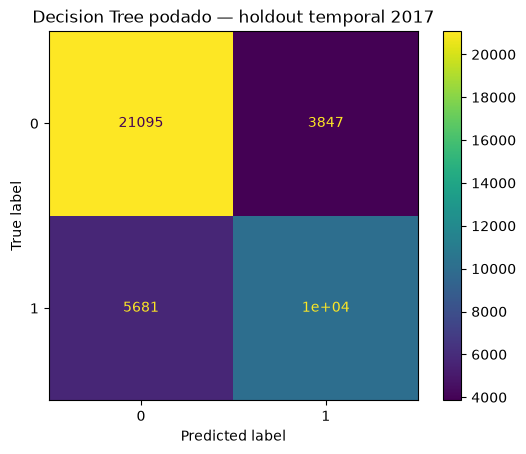

In [20]:
plot_confusion_matrix(
    final_tree_model,
    X_tree_final_holdout,
    y_holdout,
    threshold=0.5,
    title="Decision Tree podado — holdout temporal 2017",
)

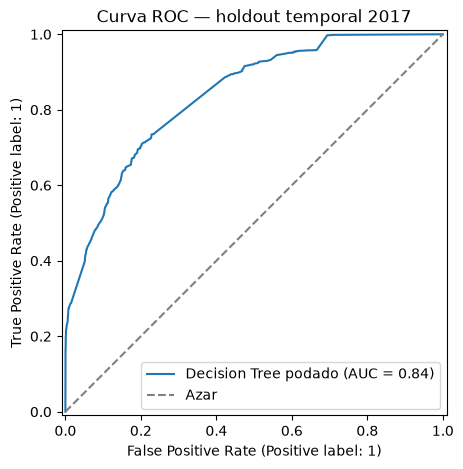

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(
    final_tree_model,
    X_tree_final_holdout,
    y_holdout,
    name="Decision Tree podado",
    ax=ax,
)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ax.set_title("Curva ROC — holdout temporal 2017")
ax.legend(loc="lower right")
plt.show()

## Conclusiones

El análisis estructural y la permutación fuera de muestra coincidieron en un núcleo formado por `Country`, `MarketSegment`, `PreviousCancellations`, `LeadTime`, `TotalOfSpecialRequests`, `ArrivalDateYear`, `RequiredCarParkingSpaces` y `CustomerType`. `LeadTime` participó en 40 splits, confirmando una relación marcadamente no lineal.

La poda estricta eliminó cuatro variables sin modificar el resultado. La poda ampliada eliminó además `ReservedRoomType`, `ArrivalDateDayOfMonth` y `Meal`, elevó ROC AUC CV de 0,923749 a 0,924418, mejoró los cinco folds y redujo la desviación. Se selecciona este conjunto de 17 features como candidato para modelos basados en árboles.

La búsqueda final seleccionó profundidad 14 y `min_samples_leaf=75`. Alcanzó ROC AUC CV 0,927092, pero descendió a 0,838694 en el holdout temporal, con un gap de 0,088398. Con threshold 0,5 logró Accuracy 0,765822, Precision 0,723456, Recall 0,639187 y F1 0,678716.

El árbol supera a Logistic Regression dentro de CV, pero queda por debajo de ambas regresiones en ROC AUC temporal y por debajo de la versión engineered en Recall y F1. Esto indica que aprendió patrones específicos de 2015–2016 que no se trasladaron adecuadamente a 2017. Se conserva como herramienta para estudiar variables y no se reajusta a partir del holdout.

Random Forest y XGBoost deberán comparar el conjunto podado contra la base depurada en lugar de asumir que la reducción se transfiere automáticamente.